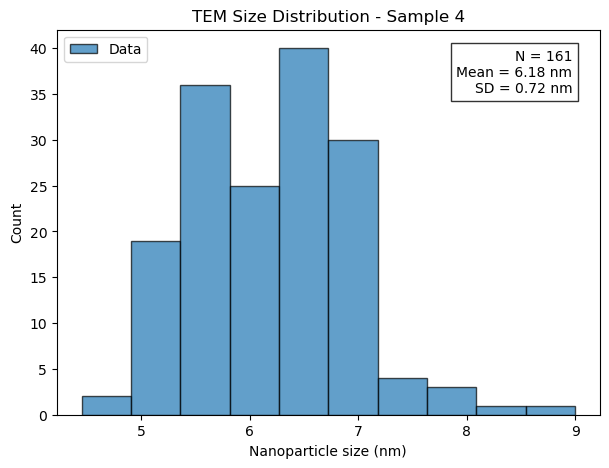

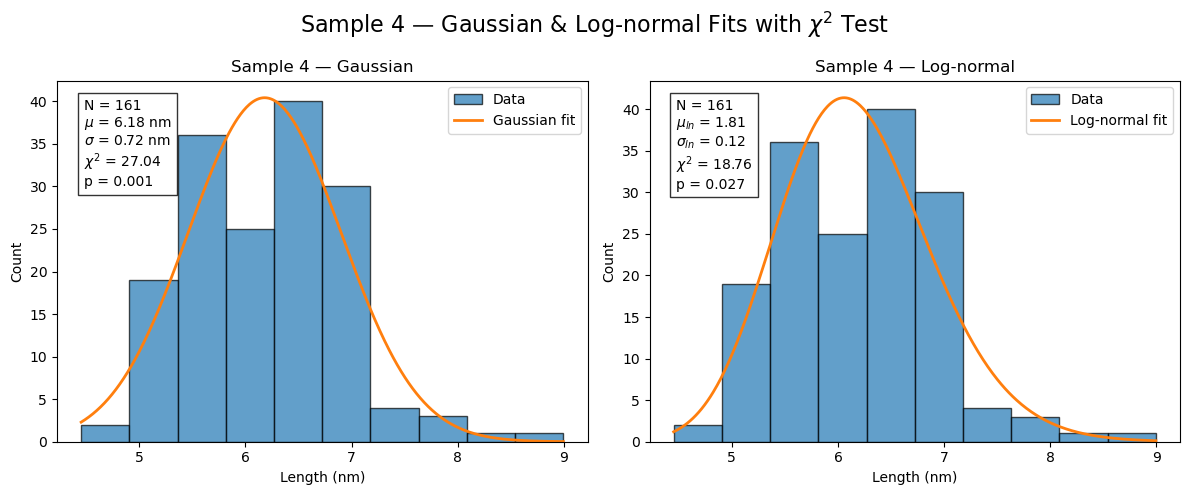

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm, chisquare

# Load data for sample 4

df = pd.read_csv("Results_Sample_4.csv")
sizes = df["Length"].dropna()
N = len(sizes)

# Histogram settings
bins = 10
observed, bin_edges = np.histogram(sizes, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
x = np.linspace(sizes.min(), sizes.max(), 500)

# Histogram plot
mean_size = np.mean(sizes)
std_size = np.std(sizes, ddof=1)
plt.figure(figsize=(7,5))
plt.hist(sizes, bins=bins, edgecolor="black", alpha=0.7, label="Data")
plt.xlabel("Nanoparticle size (nm)")
plt.ylabel("Count")
plt.title("TEM Size Distribution - Sample 4")
plt.text(0.95, 0.95, f"N = {N}\n" f"Mean = {mean_size:.2f} nm\n" f"SD = {std_size:.2f} nm", transform=plt.gca().transAxes,
    horizontalalignment="right", verticalalignment="top", bbox=dict(facecolor="white", alpha=0.8))
plt.legend()
plt.grid(False)
plt.show()

# Fit Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) Gaussian fit
mu, sigma = norm.fit(sizes)
pdf_gaussian = norm.pdf(x, mu, sigma)
cdf_values = norm.cdf(bin_edges, mu, sigma)
expected = N * np.diff(cdf_values)
expected = expected * observed.sum() / expected.sum()
chi2_gauss, p_gauss = chisquare(f_obs=observed, f_exp=expected)

axes[0].hist(sizes, bins=bin_edges, alpha=0.7, edgecolor="black", label="Data")
axes[0].plot(x, pdf_gaussian * N * bin_width, linewidth=2, label="Gaussian fit")
axes[0].set_title("Sample 4 — Gaussian")
axes[0].set_xlabel("Length (nm)")
axes[0].set_ylabel("Count")
axes[0].text(0.05, 0.95, f"N = {N}\n" f"$\\mu$ = {mu:.2f} nm\n" f"$\\sigma$ = {sigma:.2f} nm\n" f"$\\chi^2$ = {chi2_gauss:.2f}\n"
    f"p = {p_gauss:.3f}", transform=axes[0].transAxes, verticalalignment="top", bbox=dict(facecolor="white", alpha=0.8))
axes[0].legend()
axes[0].grid(False)

# 2) Log-normal fit
shape, loc, scale = lognorm.fit(sizes, floc=0)
mu_ln = np.log(scale)
sigma_ln = shape
pdf_lognorm = lognorm.pdf(x, shape, loc, scale)
cdf_values = lognorm.cdf(bin_edges, shape, loc, scale)
expected = N * np.diff(cdf_values)
expected = expected * observed.sum() / expected.sum()
chi2_lognorm, p_lognorm = chisquare(f_obs=observed, f_exp=expected)

axes[1].hist(sizes, bins=bin_edges, alpha=0.7, edgecolor="black", label="Data")
axes[1].plot(x, pdf_lognorm * N * bin_width, linewidth=2, label="Log-normal fit")
axes[1].set_title("Sample 4 — Log-normal")
axes[1].set_xlabel("Length (nm)")
axes[1].set_ylabel("Count")
axes[1].text(0.05, 0.95, f"N = {N}\n" f"$\\mu_{{ln}}$ = {mu_ln:.2f}\n" f"$\\sigma_{{ln}}$ = {sigma_ln:.2f}\n" f"$\\chi^2$ = {chi2_lognorm:.2f}\n"
    f"p = {p_lognorm:.3f}", transform=axes[1].transAxes, verticalalignment="top", bbox=dict(facecolor="white", alpha=0.8))
axes[1].legend()
axes[1].grid(False)

# Final layout
fig.suptitle("Sample 4 — Gaussian & Log-normal Fits with $\\chi^2$ Test", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
summary_table = pd.DataFrame({
    "Model": ["Gaussian", "Log-normal",],
    "Mean / μ (nm)": [f"{mu:.2f}", "-",],
    "SD / σ (nm)": [f"{sigma:.2f}", "-",],
    "μ_ln": ["-", f"{mu_ln:.2f}",],
    "σ_ln": ["-", f"{sigma_ln:.2f}",],
    "χ²": [f"{chi2_gauss:.2f}", f"{chi2_lognorm:.2f}",],
    "p-value": [f"{p_gauss:.3f}", f"{p_lognorm:.3f}",]})
print(summary_table)

        Model Mean / μ (nm) SD / σ (nm)  μ_ln  σ_ln     χ² p-value
0    Gaussian          6.18        0.72     -     -  27.04   0.001
1  Log-normal             -           -  1.81  0.12  18.76   0.027
